# Model Benchmark Investigation

This notebook complements `scripts/benchmark_models.py` with custom, thesis-oriented inspection workflows.

## 1. Aggregate Metrics Comparison

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").exists() and (cand / "scripts").exists():
            return cand
    raise FileNotFoundError("Could not detect repo root (expected folders: src/, scripts/).")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from energy_trading.visualization.style import apply_geo_style, THESIS_PALETTE

apply_geo_style()

# -------------------------------
# Benchmark run configuration
# -------------------------------
XGB_RUN_ID = "2026-04-20T15-36-58Z"
TFT_RUN_ID = "2026-04-20T15-36-58Z"
MODEL_KEY_XGB = "xgboost"
MODEL_KEY_TFT = "tft"

BENCHMARK_NAME = "xgb_vs_tft"
SPLIT = "test"
LEAD = 1
WINDOW_DAYS = 5
WEEK_HOURS = 24 * 7
WEEK_REFERENCE_PRED_COL = "pred_afrr_activation_price_neg"

RUN_DIR_XGB = REPO_ROOT / "artifacts" / "model_runs" / XGB_RUN_ID
RUN_DIR_TFT = REPO_ROOT / "artifacts" / "model_runs" / TFT_RUN_ID
BENCHMARK_DIR = REPO_ROOT / "artifacts" / "benchmarks" / BENCHMARK_NAME
SUMMARY_CSV = BENCHMARK_DIR / "benchmark_summary.csv"

TRUTH_COL_BY_PRED = {
    "pred_da_price": "target_da_price",
    "pred_afrr_activation_price_pos": "target_afrr_activation_price_vwap_pos",
    "pred_afrr_activation_price_neg": "target_afrr_activation_price_vwap_neg",
    "pred_afrr_capacity_price_pos": "target_afrr_capacity_price_pos",
    "pred_afrr_capacity_price_neg": "target_afrr_capacity_price_neg",
    "pred_afrr_activation_rate_pos": "target_afrr_activation_rate_pos",
    "pred_afrr_activation_rate_neg": "target_afrr_activation_rate_neg",
}


def load_manifest(run_dir: Path) -> dict:
    mp = run_dir / "manifest.json"
    if not mp.exists():
        raise FileNotFoundError(f"Missing manifest: {mp}")
    return json.loads(mp.read_text())


def resolve_truth_path(run_dir: Path, manifest: dict) -> Path:
    sm = run_dir / "summary_metrics.json"
    if sm.exists():
        payload = json.loads(sm.read_text())
        gp = payload.get("ground_truth_path", "")
        if gp and Path(gp).exists():
            return Path(gp)
    mp = manifest.get("ground_truth", {}).get("default_path", "")
    if mp and Path(mp).exists():
        return Path(mp)
    return REPO_ROOT / "data" / "features" / "all_data_features.parquet"


def load_truth_df(path: Path) -> pd.DataFrame:
    truth = pd.read_parquet(path)
    truth["timestamp_utc"] = pd.to_datetime(truth["timestamp_utc"], utc=True, errors="coerce")
    missing = [c for c in TRUTH_COL_BY_PRED.values() if c not in truth.columns]
    if missing:
        raise KeyError(f"Missing truth columns in {path}: {sorted(set(missing))}")
    return truth


def _matches_model_key(path: Path, model_key: str) -> bool:
    if not model_key:
        return True
    mk = model_key.strip().lower()
    name = path.name.lower()
    if mk in {"xgb", "xgboost"}:
        return "xgboost" in name
    if mk == "tft":
        return "xgboost" not in name
    return mk in name


def _discover_long_prediction_file(run_dir: Path, split: str, pred_col: str, model_key: str) -> Path:
    pred_dir = run_dir / "predictions"
    if not pred_dir.exists():
        raise FileNotFoundError(f"Missing predictions dir: {pred_dir}")

    pats = [
        f"*{split}*{pred_col}*long*.parquet",
        f"*{pred_col}*long*{split}*.parquet",
        f"*{pred_col}*{split}*long*.parquet",
    ]
    candidates: list[Path] = []
    for pat in pats:
        candidates.extend(sorted(pred_dir.glob(pat)))

    if model_key:
        candidates = [c for c in candidates if _matches_model_key(c, model_key)]

    if not candidates:
        raise FileNotFoundError(
            f"No long prediction file for pred_col={pred_col}, split={split}, model_key={model_key} in {pred_dir}"
        )
    return candidates[0]


def load_long_df(run_dir: Path, pred_col: str, model_key: str) -> pd.DataFrame:
    p = _discover_long_prediction_file(run_dir, SPLIT, pred_col, model_key)
    df = pd.read_parquet(p)
    ts_col = next((c for c in ["target_time_utc", "timestamp_utc", "timestamp"] if c in df.columns), None)
    if ts_col is None:
        raise KeyError(f"Missing timestamp col in {p}. Found: {list(df.columns)}")
    df = df.copy()
    df["target_time_utc"] = pd.to_datetime(df[ts_col], utc=True, errors="coerce")
    if "lead_time_h" in df.columns:
        df["lead_time_h"] = pd.to_numeric(df["lead_time_h"], errors="coerce")
    else:
        df["lead_time_h"] = 1
    if "p50" not in df.columns and "predicted_value" in df.columns:
        df["p50"] = pd.to_numeric(df["predicted_value"], errors="coerce")
    return df


def _model_has_pred_col(run_dir: Path, pred_col: str, model_key: str) -> bool:
    try:
        _discover_long_prediction_file(run_dir, SPLIT, pred_col, model_key)
        return True
    except Exception:
        return False


def compute_metrics_by_lead_for_model(pred_col: str, run_dir: Path, model_key: str) -> pd.DataFrame:
    truth_col = TRUTH_COL_BY_PRED[pred_col]
    long_df = load_long_df(run_dir, pred_col, model_key)
    pred_col_name = "p50" if "p50" in long_df.columns else "predicted_value"
    d = long_df[["target_time_utc", "lead_time_h", pred_col_name]].copy().rename(columns={pred_col_name: "y_pred"})

    t = truth_df[["timestamp_utc", truth_col]].copy().rename(columns={"timestamp_utc": "target_time_utc", truth_col: "y_true"})
    d = d.merge(t, on="target_time_utc", how="left")

    truth_by_ts = t.dropna(subset=["target_time_utc"]).set_index("target_time_utc")["y_true"]
    d["y_naive_24h"] = truth_by_ts.reindex(d["target_time_utc"] - pd.Timedelta(hours=24)).to_numpy()

    out = []
    for lead, g in d.groupby("lead_time_h", dropna=True):
        yt = pd.to_numeric(g["y_true"], errors="coerce").to_numpy(dtype=float)
        yp = pd.to_numeric(g["y_pred"], errors="coerce").to_numpy(dtype=float)
        yn = pd.to_numeric(g["y_naive_24h"], errors="coerce").to_numpy(dtype=float)
        m = np.isfinite(yt) & np.isfinite(yp)
        mn = m & np.isfinite(yn)
        if not np.any(m):
            continue
        mae = float(np.mean(np.abs(yt[m] - yp[m])))
        skill = np.nan
        if np.any(mn):
            mae_naive = float(np.mean(np.abs(yt[mn] - yn[mn])))
            if np.isfinite(mae_naive) and mae_naive != 0:
                skill = float(1.0 - mae / mae_naive)
        out.append({"lead_time_h": float(lead), "mae": mae, "skill_score_mae": skill})
    return pd.DataFrame(out).sort_values("lead_time_h").reset_index(drop=True)


mx = load_manifest(RUN_DIR_XGB)
truth_path = resolve_truth_path(RUN_DIR_XGB, mx)
truth_df = load_truth_df(truth_path)

COMMON_PRED_COLS = [
    p for p in sorted(TRUTH_COL_BY_PRED)
    if _model_has_pred_col(RUN_DIR_XGB, p, MODEL_KEY_XGB)
    and _model_has_pred_col(RUN_DIR_TFT, p, MODEL_KEY_TFT)
]
if not COMMON_PRED_COLS:
    raise ValueError("No common prediction columns found for configured model keys in the selected run dirs.")

summary_df = pd.read_csv(SUMMARY_CSV) if SUMMARY_CSV.exists() else pd.DataFrame()
summary_df


,prediction_column,metric,XGBoost,TFT,Delta (%)
0,pred_afrr_activation_price_neg,MAE,359.552984,253.964584,29.366576
1,pred_afrr_activation_price_neg,RMSE,487.589470,364.933298,25.155624
2,pred_afrr_activation_price_neg,Pinball,179.776492,126.982292,29.366576
3,pred_afrr_activation_price_neg,WIS,258.361752,187.009254,27.617284
4,pred_afrr_activation_price_neg,ACE,0.229085,0.086721,62.144365
...,...,...,...,...,...
65,pred_da_price,Skill Score,0.101328,0.185098,82.671713
66,pred_da_price,Spike MAE (Top 5%),59.937929,69.161327,-15.388250
67,pred_da_price,Spike RMSE (Top 5%),89.703994,106.086104,-18.262410
68,pred_da_price,Negative Tail MAE (Bottom 5%),10.823985,45.859292,-323.682134


## 2. Horizon Degradation (All Targets)

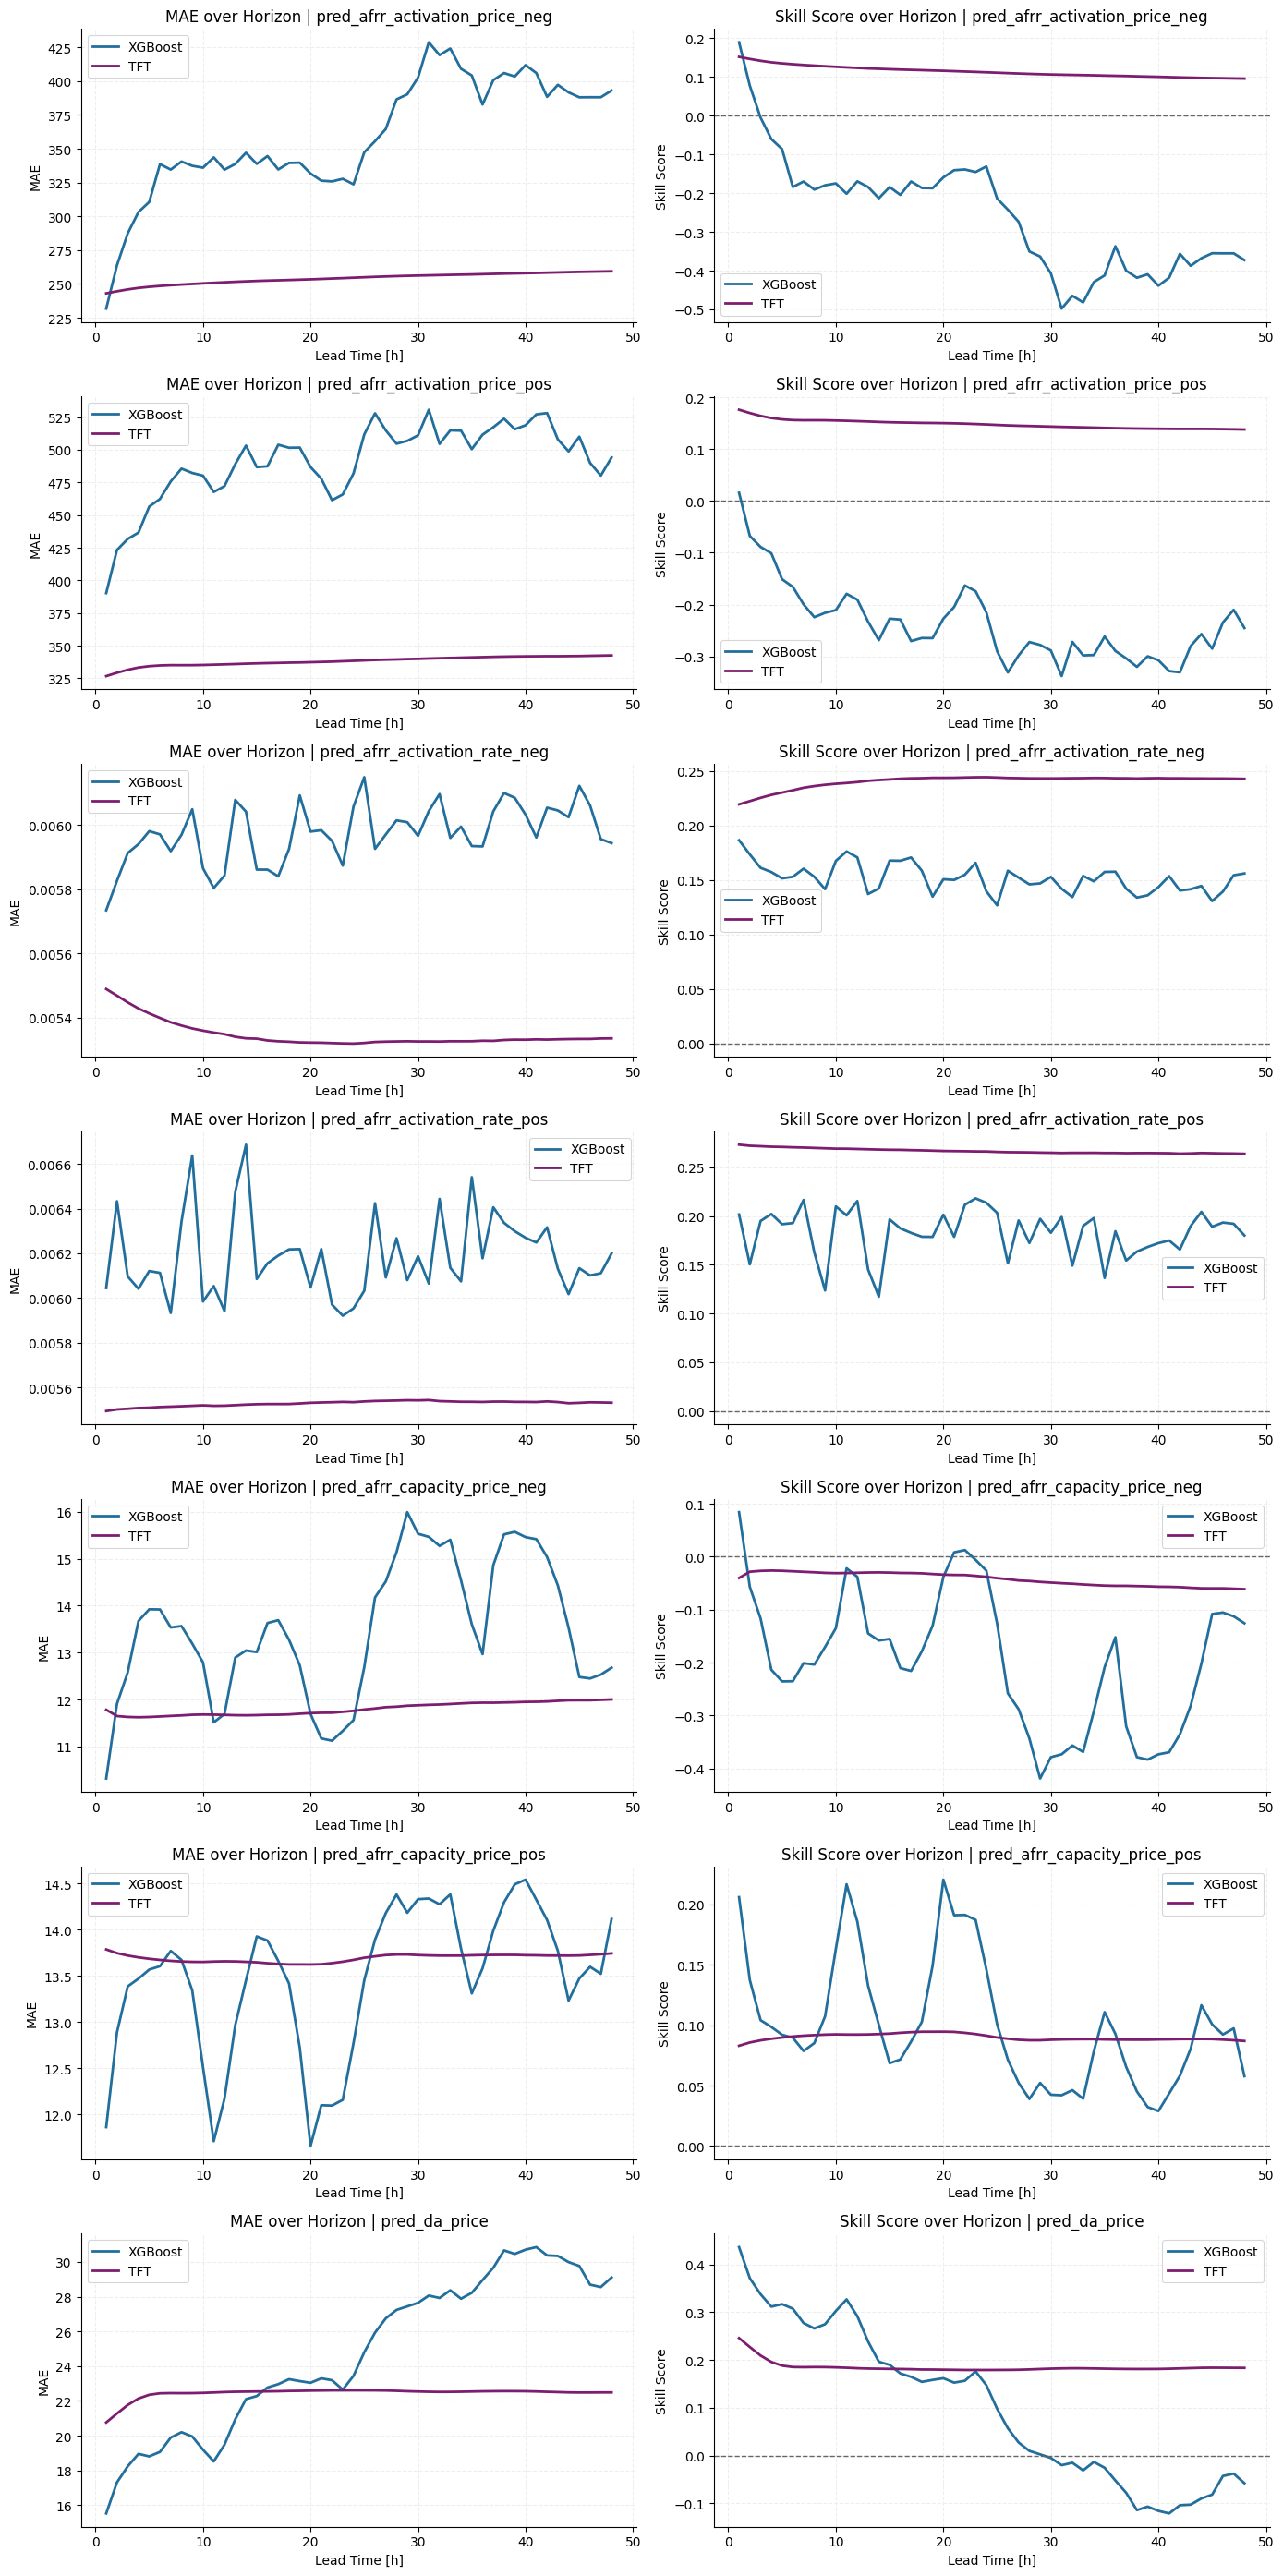

In [2]:
import math

fig, axes = plt.subplots(len(COMMON_PRED_COLS), 2, figsize=(14, 4 * len(COMMON_PRED_COLS)), squeeze=False)

for r, pred_col in enumerate(COMMON_PRED_COLS):
    xgb_lead = compute_metrics_by_lead_for_model(pred_col, RUN_DIR_XGB, MODEL_KEY_XGB)
    tft_lead = compute_metrics_by_lead_for_model(pred_col, RUN_DIR_TFT, MODEL_KEY_TFT)

    if xgb_lead.empty or tft_lead.empty:
        axes[r, 0].text(0.5, 0.5, f"missing lead metrics for {pred_col}", ha="center")
        axes[r, 1].text(0.5, 0.5, f"missing lead metrics for {pred_col}", ha="center")
        continue

    ax0 = axes[r, 0]
    ax0.plot(xgb_lead["lead_time_h"], xgb_lead["mae"], label="XGBoost", color=THESIS_PALETTE["primary"], linewidth=2)
    ax0.plot(tft_lead["lead_time_h"], tft_lead["mae"], label="TFT", color=THESIS_PALETTE["tertiary"], linewidth=2)
    ax0.set_title(f"MAE over Horizon | {pred_col}")
    ax0.set_xlabel("Lead Time [h]")
    ax0.set_ylabel("MAE")
    ax0.legend()

    ax1 = axes[r, 1]
    if "skill_score_mae" in xgb_lead.columns and "skill_score_mae" in tft_lead.columns:
        ax1.plot(xgb_lead["lead_time_h"], xgb_lead["skill_score_mae"], label="XGBoost", color=THESIS_PALETTE["primary"], linewidth=2)
        ax1.plot(tft_lead["lead_time_h"], tft_lead["skill_score_mae"], label="TFT", color=THESIS_PALETTE["tertiary"], linewidth=2)
        ax1.axhline(0.0, color="#666", linestyle="--", linewidth=1)
    else:
        ax1.text(0.5, 0.5, "skill_score_mae missing", ha="center")
    ax1.set_title(f"Skill Score over Horizon | {pred_col}")
    ax1.set_xlabel("Lead Time [h]")
    ax1.set_ylabel("Skill Score")
    ax1.legend()

plt.tight_layout()


## 3. Weekly Truth vs Predictions (Mon-Sun, All Targets)

Global week reference target: pred_afrr_activation_price_neg
High-vol week start (UTC Monday): 2025-09-22 00:00:00+00:00
Typical week start (UTC Monday): 2026-02-16 00:00:00+00:00


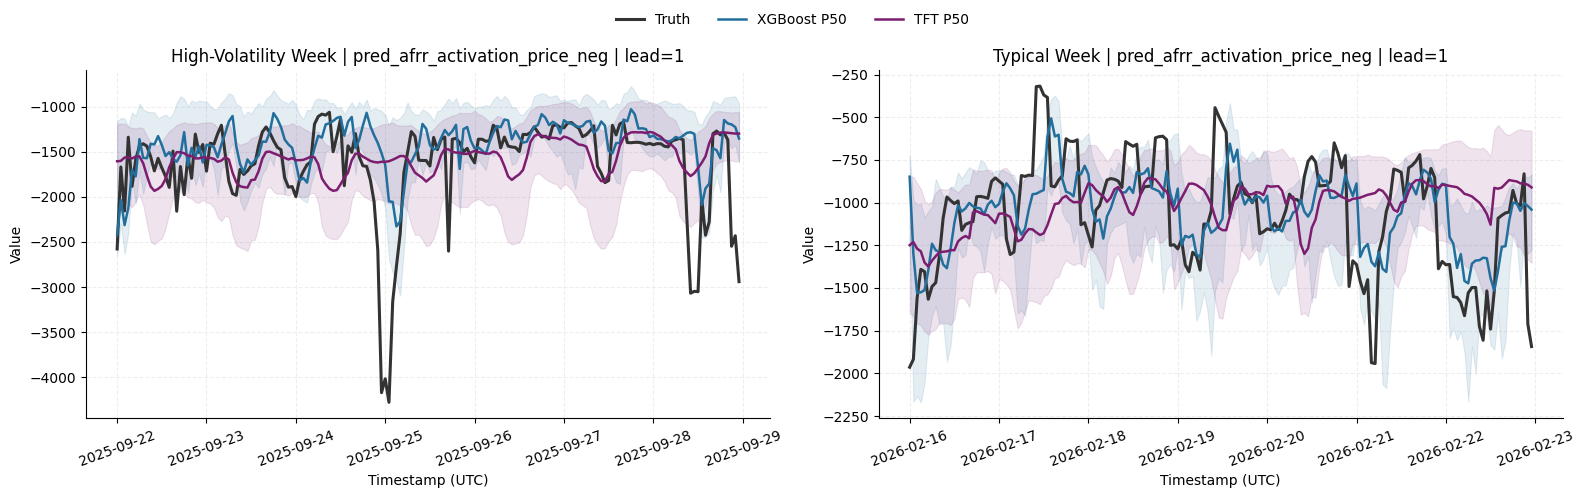

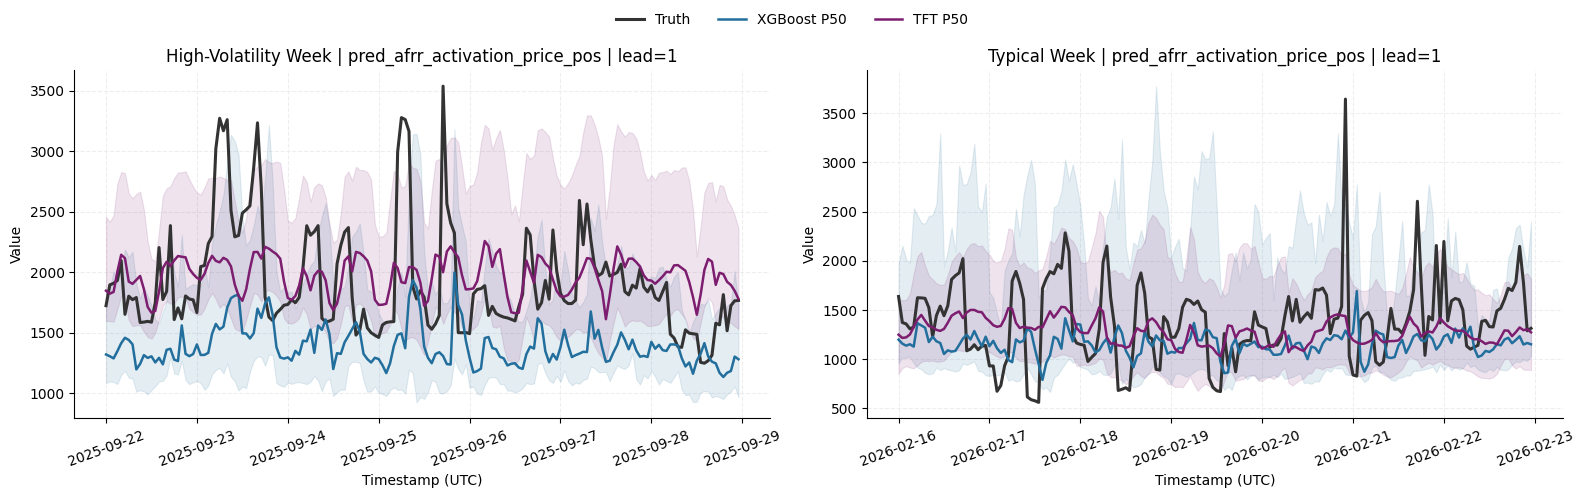

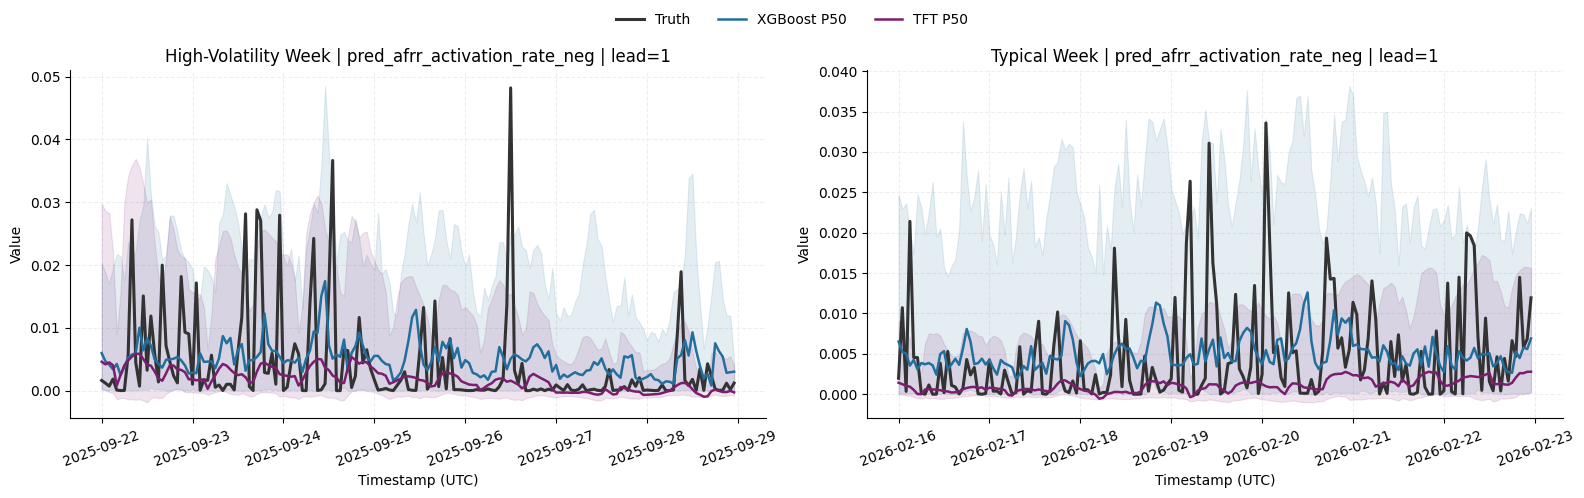

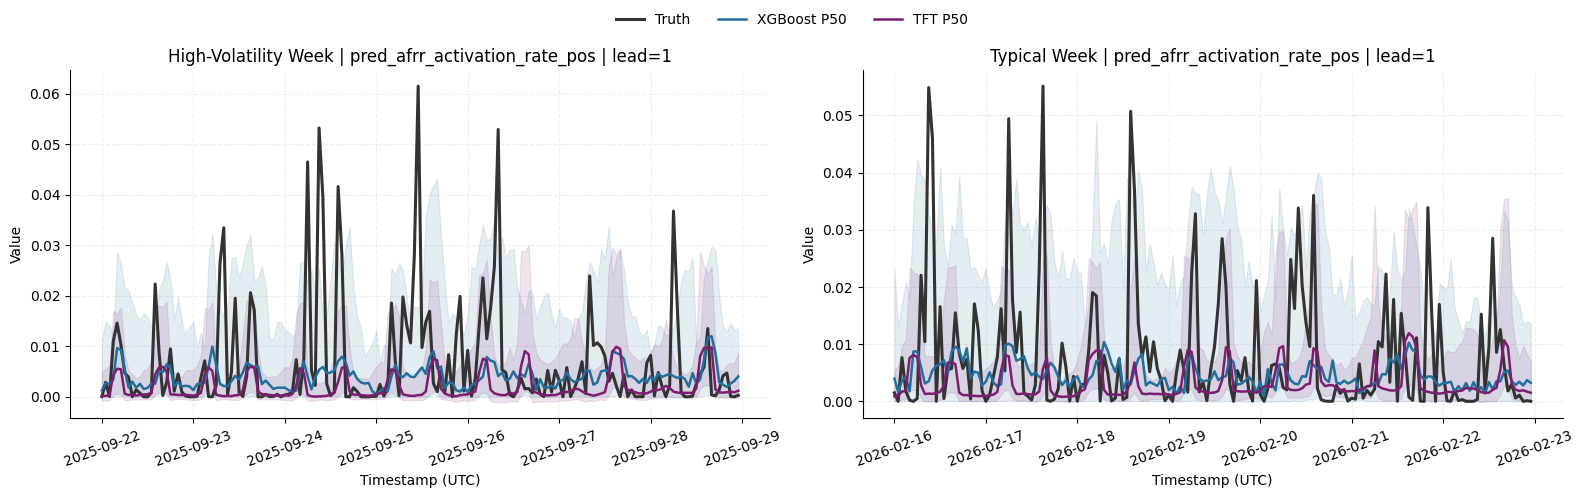

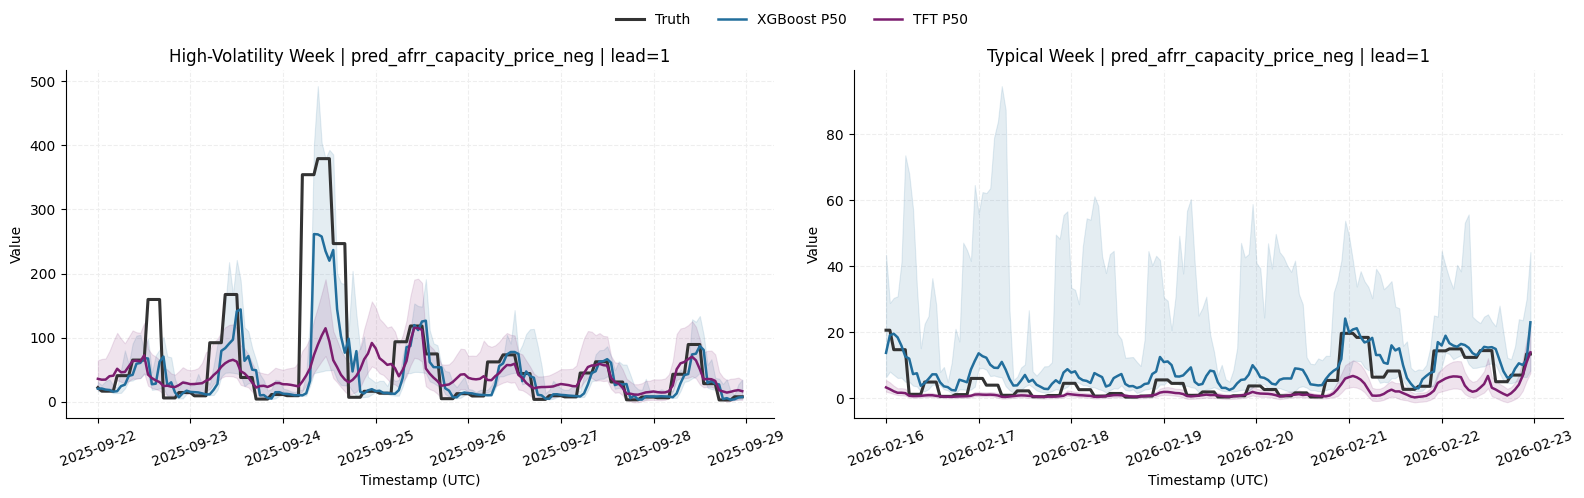

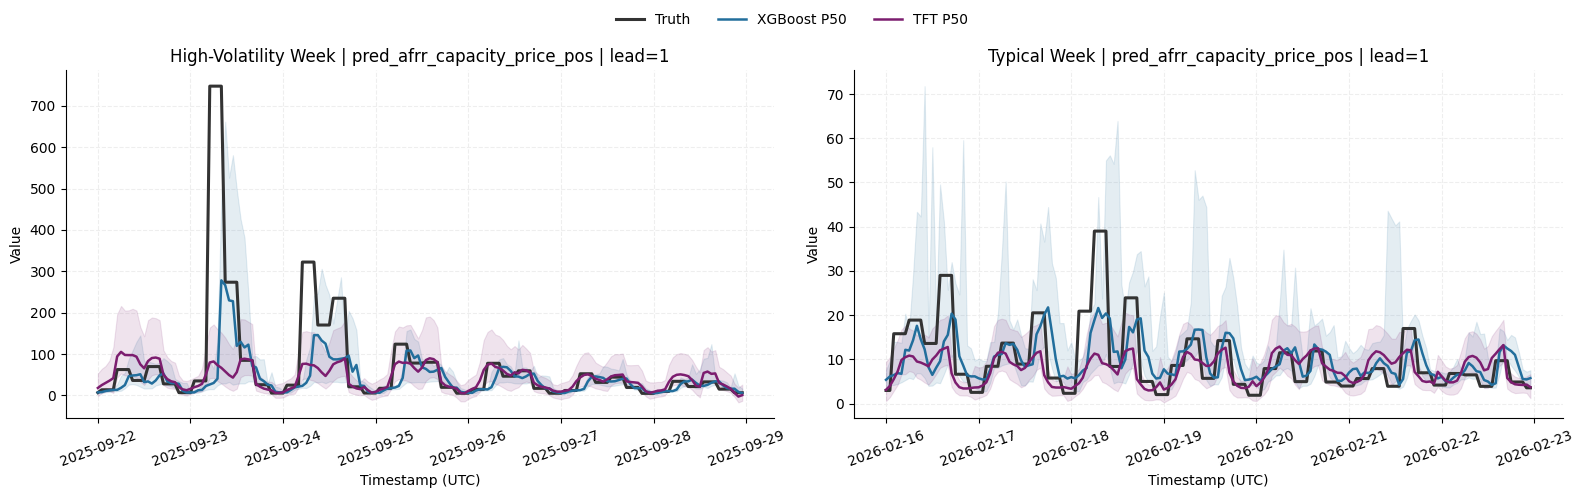

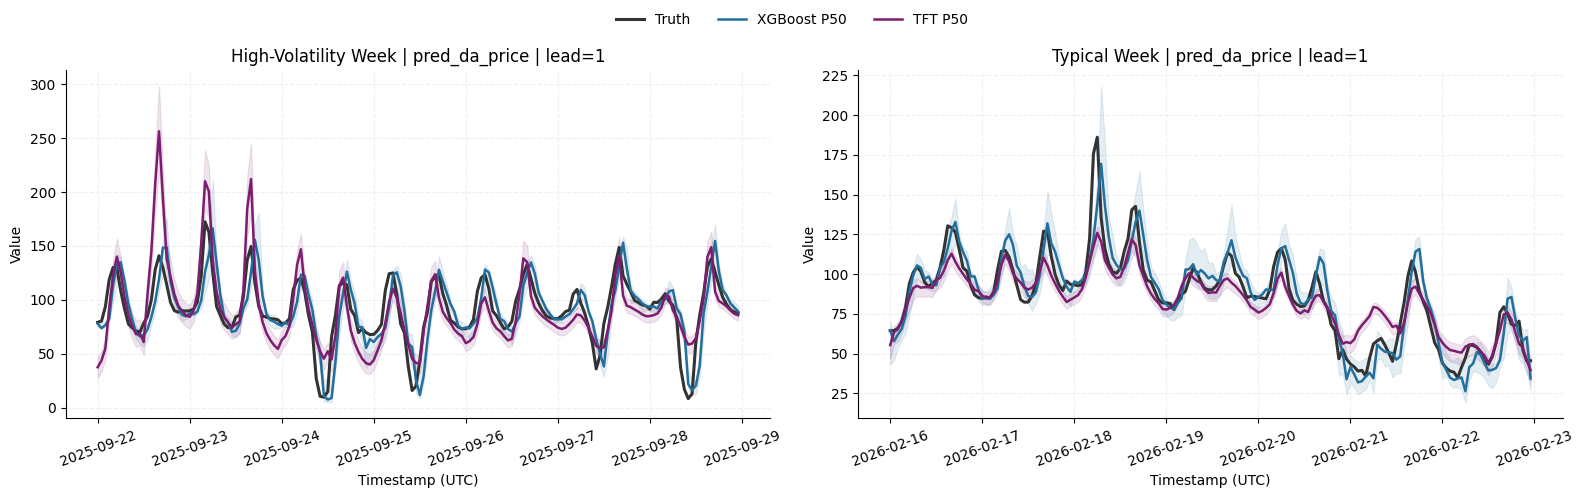

In [3]:
def load_merged_for_target(pred_col: str, lead: int = 1) -> pd.DataFrame:
    truth_col = TRUTH_COL_BY_PRED[pred_col]

    xgb = load_long_df(RUN_DIR_XGB, pred_col, MODEL_KEY_XGB)
    tft = load_long_df(RUN_DIR_TFT, pred_col, MODEL_KEY_TFT)

    xgb_l = xgb.loc[xgb["lead_time_h"] == lead, ["target_time_utc", "p50"]].rename(columns={"p50": "xgb_p50"})
    tft_l = tft.loc[tft["lead_time_h"] == lead, ["target_time_utc", "p50"]].rename(columns={"p50": "tft_p50"})

    xgb_q = xgb.loc[xgb["lead_time_h"] == lead, ["target_time_utc", "p10", "p90"]] if {"p10", "p90"}.issubset(xgb.columns) else None
    tft_q = tft.loc[tft["lead_time_h"] == lead, ["target_time_utc", "p10", "p90"]] if {"p10", "p90"}.issubset(tft.columns) else None

    tru = truth_df[["timestamp_utc", truth_col]].rename(columns={"timestamp_utc": "target_time_utc", truth_col: "y_true"})

    merged = tru.merge(xgb_l, on="target_time_utc", how="inner").merge(tft_l, on="target_time_utc", how="inner")
    if xgb_q is not None:
        merged = merged.merge(xgb_q.rename(columns={"p10": "xgb_p10", "p90": "xgb_p90"}), on="target_time_utc", how="left")
    if tft_q is not None:
        merged = merged.merge(tft_q.rename(columns={"p10": "tft_p10", "p90": "tft_p90"}), on="target_time_utc", how="left")

    return merged.sort_values("target_time_utc").reset_index(drop=True)


def _monday_start(ts: pd.Timestamp) -> pd.Timestamp:
    ts = pd.Timestamp(ts).tz_convert("UTC")
    return (ts - pd.Timedelta(days=int(ts.weekday()))).floor("D")


def _week_slice_by_start(df: pd.DataFrame, week_start_utc: pd.Timestamp) -> pd.DataFrame:
    start = pd.Timestamp(week_start_utc).tz_convert("UTC")
    end = start + pd.Timedelta(days=7)
    out = df[(df["target_time_utc"] >= start) & (df["target_time_utc"] < end)].copy()
    return out


def _compute_global_week_starts(reference_pred_col: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    ref = load_merged_for_target(reference_pred_col, lead=LEAD)
    if ref.empty:
        fallback = load_merged_for_target(COMMON_PRED_COLS[0], lead=LEAD)
        ref = fallback
    if ref.empty:
        raise ValueError("No merged data available to determine weekly windows.")

    d = ref.sort_values("target_time_utc").reset_index(drop=True)
    rolling_std = d["y_true"].rolling(window=WEEK_HOURS, min_periods=24 * 3).std()

    if rolling_std.notna().any():
        high_anchor = d.loc[int(rolling_std.idxmax()), "target_time_utc"]
        rs = rolling_std.dropna()
        med = rs.median()
        typical_idx = (rs - med).abs().idxmin()
        typical_anchor = d.loc[int(typical_idx), "target_time_utc"]
    else:
        high_anchor = d["target_time_utc"].iloc[min(len(d) - 1, max(0, WEEK_HOURS - 1))]
        typical_anchor = d["target_time_utc"].iloc[len(d) // 2]

    high_start = _monday_start(high_anchor)
    typical_start = _monday_start(typical_anchor)
    if high_start == typical_start:
        alt_anchor = d["target_time_utc"].iloc[len(d) // 2]
        typical_start = _monday_start(alt_anchor)

    return high_start, typical_start


reference_col = WEEK_REFERENCE_PRED_COL if WEEK_REFERENCE_PRED_COL in COMMON_PRED_COLS else COMMON_PRED_COLS[0]
HIGH_WEEK_START_UTC, TYPICAL_WEEK_START_UTC = _compute_global_week_starts(reference_col)

print(f"Global week reference target: {reference_col}")
print(f"High-vol week start (UTC Monday): {HIGH_WEEK_START_UTC}")
print(f"Typical week start (UTC Monday): {TYPICAL_WEEK_START_UTC}")

for pred_col in COMMON_PRED_COLS:
    merged = load_merged_for_target(pred_col, lead=LEAD)
    if merged.empty:
        continue

    high_week = _week_slice_by_start(merged, HIGH_WEEK_START_UTC)
    typical_week = _week_slice_by_start(merged, TYPICAL_WEEK_START_UTC)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    for ax, view, title_suffix, start_utc in [
        (axes[0], high_week, "High-Volatility Week", HIGH_WEEK_START_UTC),
        (axes[1], typical_week, "Typical Week", TYPICAL_WEEK_START_UTC),
    ]:
        if view.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(f"{title_suffix} | {pred_col}")
            continue

        ax.plot(view["target_time_utc"], view["y_true"], label="Truth", color=THESIS_PALETTE["neutral_dark"], linewidth=2.2)
        ax.plot(view["target_time_utc"], view["xgb_p50"], label="XGBoost P50", color=THESIS_PALETTE["primary"], linewidth=1.8)
        ax.plot(view["target_time_utc"], view["tft_p50"], label="TFT P50", color=THESIS_PALETTE["tertiary"], linewidth=1.8)

        if {"xgb_p10", "xgb_p90"}.issubset(view.columns):
            ax.fill_between(view["target_time_utc"], view["xgb_p10"], view["xgb_p90"], color=THESIS_PALETTE["primary"], alpha=0.12)
        if {"tft_p10", "tft_p90"}.issubset(view.columns):
            ax.fill_between(view["target_time_utc"], view["tft_p10"], view["tft_p90"], color=THESIS_PALETTE["tertiary"], alpha=0.12)

        ax.set_title(f"{title_suffix} | {pred_col} | lead={LEAD}")
        ax.set_xlabel("Timestamp (UTC)")
        ax.set_ylabel("Value")
        ax.tick_params(axis="x", rotation=20)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


## 4. Event Window Deep Dive (Selected Target, Mon-Sun)

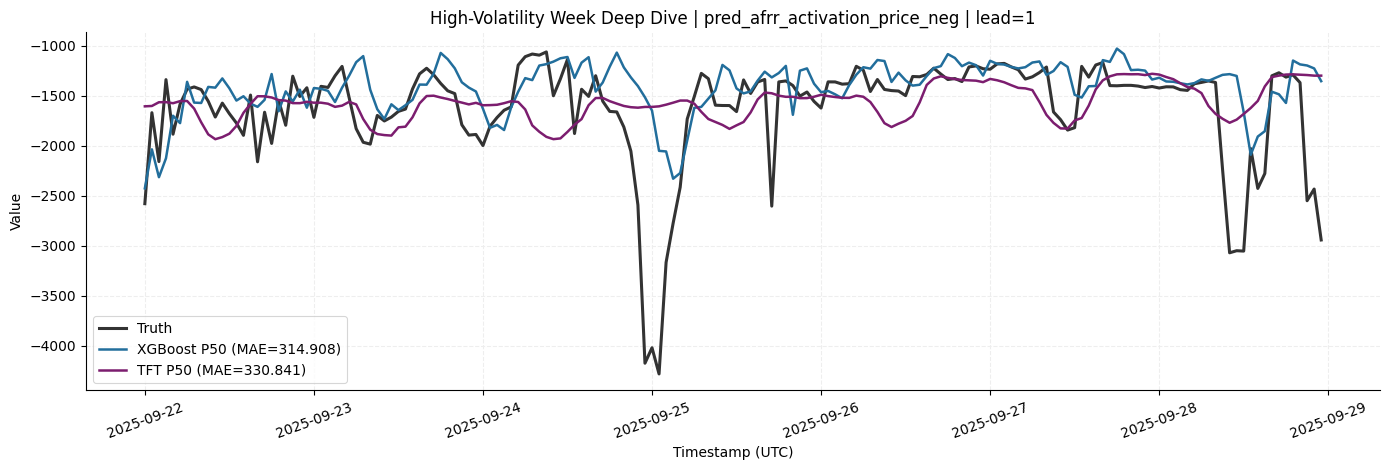

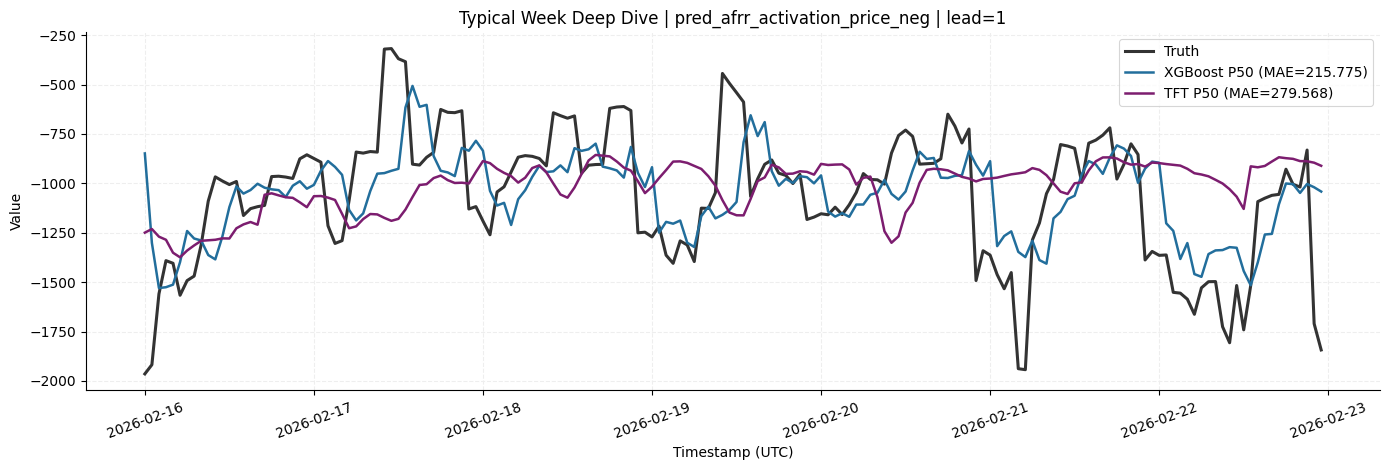

In [4]:
# Optional focused deep-dive for one target (uses SAME global weeks as section 3)
SELECTED_PRED_COL = "pred_afrr_activation_price_neg"

merged = load_merged_for_target(SELECTED_PRED_COL, lead=LEAD)
high_week = _week_slice_by_start(merged, HIGH_WEEK_START_UTC)
typical_week = _week_slice_by_start(merged, TYPICAL_WEEK_START_UTC)

for label, view, start_utc in [
    ("High-Volatility", high_week, HIGH_WEEK_START_UTC),
    ("Typical", typical_week, TYPICAL_WEEK_START_UTC),
]:
    if view.empty:
        continue
    mae_xgb = (view["xgb_p50"] - view["y_true"]).abs().mean()
    mae_tft = (view["tft_p50"] - view["y_true"]).abs().mean()

    plt.figure(figsize=(14, 4.8))
    plt.plot(view["target_time_utc"], view["y_true"], label="Truth", color=THESIS_PALETTE["neutral_dark"], linewidth=2.2)
    plt.plot(view["target_time_utc"], view["xgb_p50"], label=f"XGBoost P50 (MAE={mae_xgb:.3f})", color=THESIS_PALETTE["primary"], linewidth=1.8)
    plt.plot(view["target_time_utc"], view["tft_p50"], label=f"TFT P50 (MAE={mae_tft:.3f})", color=THESIS_PALETTE["tertiary"], linewidth=1.8)
    plt.title(f"{label} Week Deep Dive | {SELECTED_PRED_COL} | lead={LEAD}")
    plt.xlabel("Timestamp (UTC)")
    plt.ylabel("Value")
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4. Residual & Bias Analysis

In [5]:
# Build df for residual/regime analysis if not already provided
# Expected columns afterwards: target_time_utc, y_true, xgb_p50, tft_p50
ANALYSIS_PRED_COL = globals().get("SELECTED_PRED_COL", globals().get("WEEK_REFERENCE_PRED_COL", None))
if ANALYSIS_PRED_COL is None:
    ANALYSIS_PRED_COL = COMMON_PRED_COLS[0]

if "df" not in globals() or df is None:
    df = load_merged_for_target(ANALYSIS_PRED_COL, lead=LEAD)

required_cols = {"target_time_utc", "y_true", "xgb_p50", "tft_p50"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        f"df is missing required columns for Sections 4/5: {sorted(missing)}. "
        f"Current columns: {list(df.columns)}"
    )

print(f"Using ANALYSIS_PRED_COL={ANALYSIS_PRED_COL}, rows={len(df):,}")


Using ANALYSIS_PRED_COL=pred_afrr_activation_price_neg, rows=14,402


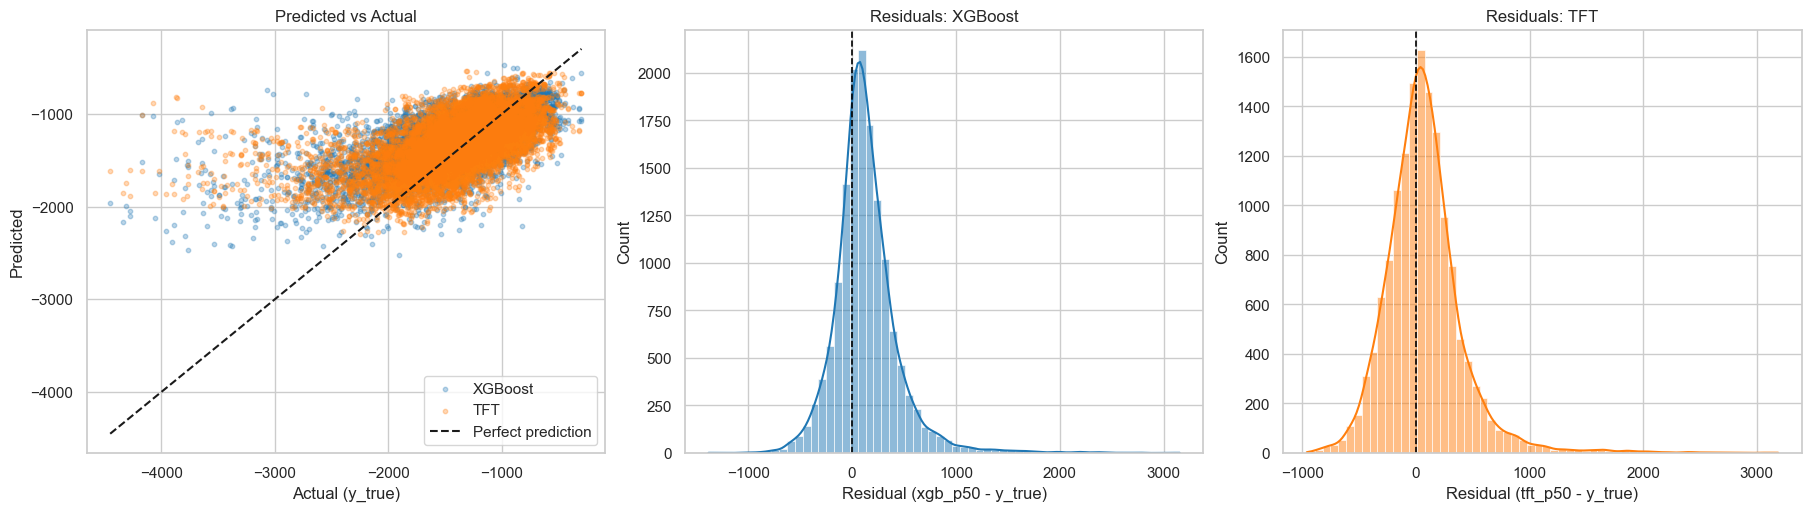

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Expected columns in df: target_time_utc, y_true, xgb_p50, tft_p50
d = globals()["df"].copy()
d["target_time_utc"] = pd.to_datetime(d["target_time_utc"], utc=True, errors="coerce")
for c in ["y_true", "xgb_p50", "tft_p50"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["target_time_utc", "y_true", "xgb_p50", "tft_p50"]).sort_values("target_time_utc")

d["res_xgb"] = d["xgb_p50"] - d["y_true"]
d["res_tft"] = d["tft_p50"] - d["y_true"]

sns.set_theme(style="whitegrid")
xgb_color = "#1f77b4"
tft_color = "#ff7f0e"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# 1) Predicted vs Actual
ax = axes[0]
ax.scatter(d["y_true"], d["xgb_p50"], s=10, alpha=0.3, color=xgb_color, label="XGBoost")
ax.scatter(d["y_true"], d["tft_p50"], s=10, alpha=0.3, color=tft_color, label="TFT")
vmin = float(np.nanmin([d["y_true"].min(), d["xgb_p50"].min(), d["tft_p50"].min()]))
vmax = float(np.nanmax([d["y_true"].max(), d["xgb_p50"].max(), d["tft_p50"].max()]))
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual (y_true)")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
ax.legend(frameon=True)

# 2) Residual histogram XGB
ax = axes[1]
sns.histplot(d["res_xgb"], bins=60, kde=True, color=xgb_color, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (xgb_p50 - y_true)")
ax.set_ylabel("Count")
ax.set_title("Residuals: XGBoost")

# 3) Residual histogram TFT
ax = axes[2]
sns.histplot(d["res_tft"], bins=60, kde=True, color=tft_color, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (tft_p50 - y_true)")
ax.set_ylabel("Count")
ax.set_title("Residuals: TFT")

plt.show()


## 5. Temporal Error Regimes

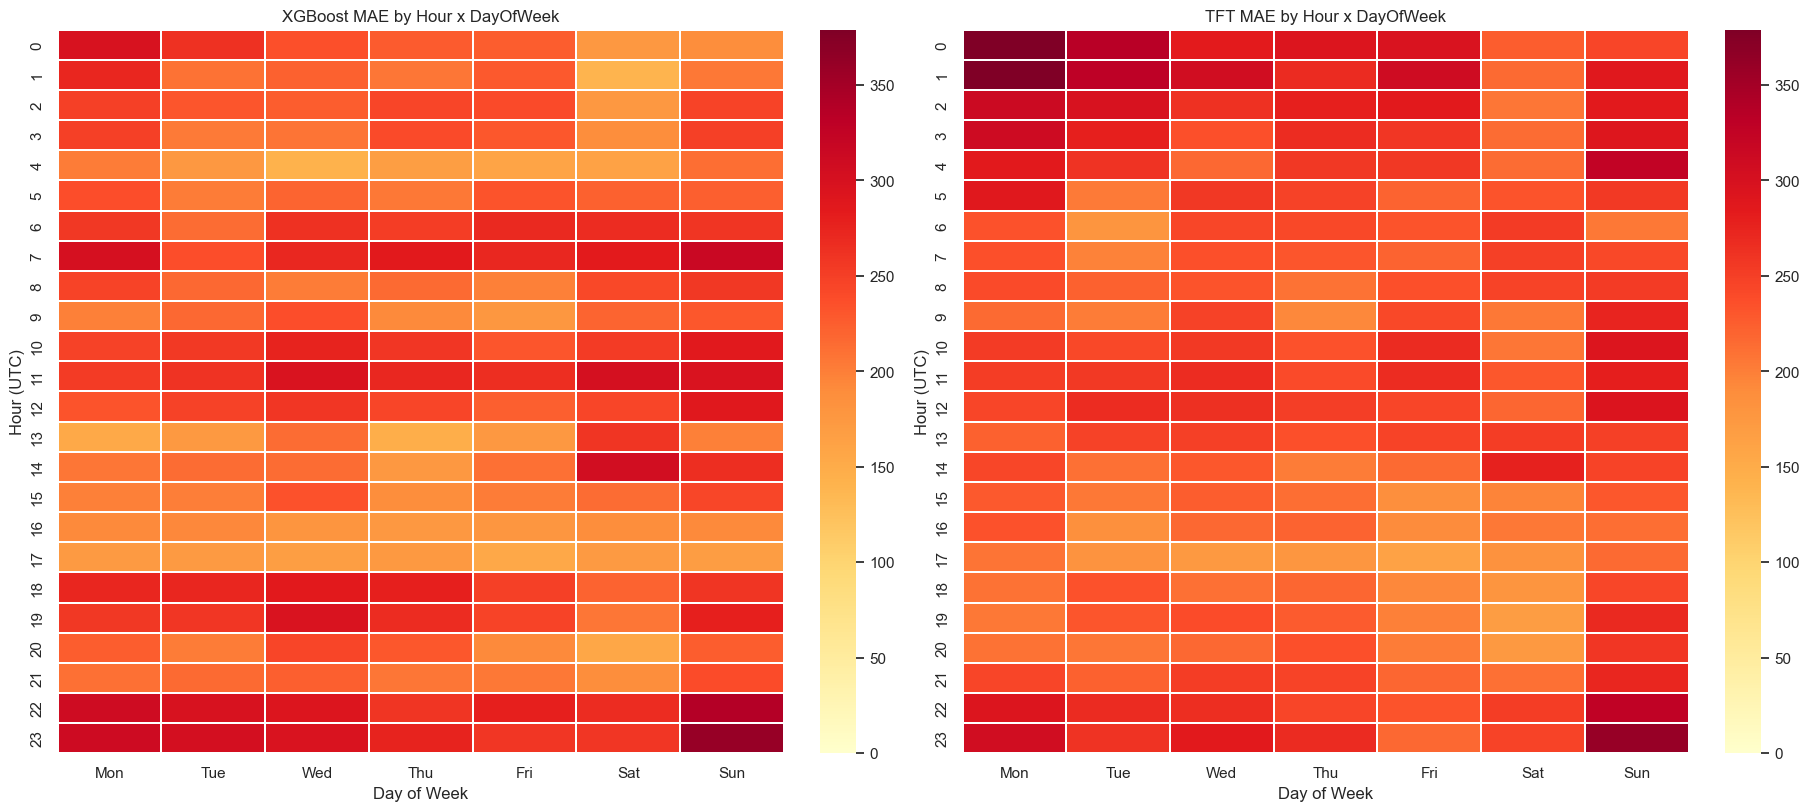

Delta Heatmap (XGB MAE - TFT MAE):


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
hour,,,,,,,
0,-80.8765,-70.2616,-48.3551,-64.1726,-70.3368,-50.5773,-55.8707
1,-104.0416,-120.8954,-83.7203,-61.0980,-81.7069,-75.5440,-82.7015
2,-64.0743,-66.6313,-35.6156,-33.0638,-44.8913,-30.4041,-37.6670
3,-61.3525,-75.3425,-27.1551,-25.4419,-27.8820,-25.0534,-41.7458
4,-82.4486,-84.7350,-74.8308,-89.0436,-96.1254,-51.7949,-112.7050
5,-50.5027,-2.0924,-36.6294,-41.5730,12.3002,-9.4678,-31.4353
6,21.5871,34.9948,18.6074,11.2417,37.1754,12.7792,54.2815
7,64.5418,38.7526,36.4750,53.9191,50.0393,33.9858,73.9368
8,5.6355,-6.2819,-30.7611,6.4616,-37.9624,-4.7706,2.3829


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

d = globals()["df"].copy()
d["target_time_utc"] = pd.to_datetime(d["target_time_utc"], utc=True, errors="coerce")
for c in ["y_true", "xgb_p50", "tft_p50"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["target_time_utc", "y_true", "xgb_p50", "tft_p50"]).sort_values("target_time_utc")

d["hour"] = d["target_time_utc"].dt.hour
d["dayofweek"] = d["target_time_utc"].dt.dayofweek  # Mon=0 ... Sun=6

d["ae_xgb"] = (d["xgb_p50"] - d["y_true"]).abs()
d["ae_tft"] = (d["tft_p50"] - d["y_true"]).abs()

hour_index = list(range(24))
dow_index = list(range(7))
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

xgb_heat = (
    d.groupby(["hour", "dayofweek"], as_index=False)["ae_xgb"].mean()
    .pivot(index="hour", columns="dayofweek", values="ae_xgb")
    .reindex(index=hour_index, columns=dow_index)
)
tft_heat = (
    d.groupby(["hour", "dayofweek"], as_index=False)["ae_tft"].mean()
    .pivot(index="hour", columns="dayofweek", values="ae_tft")
    .reindex(index=hour_index, columns=dow_index)
)

xgb_heat.columns = dow_labels
tft_heat.columns = dow_labels

vmax = float(np.nanmax([xgb_heat.to_numpy(), tft_heat.to_numpy()]))

sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

sns.heatmap(
    xgb_heat, ax=axes[0], cmap="YlOrRd", vmin=0, vmax=vmax,
    cbar=True, linewidths=0.2, linecolor="white"
)
axes[0].set_title("XGBoost MAE by Hour x DayOfWeek")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Hour (UTC)")

sns.heatmap(
    tft_heat, ax=axes[1], cmap="YlOrRd", vmin=0, vmax=vmax,
    cbar=True, linewidths=0.2, linecolor="white"
)
axes[1].set_title("TFT MAE by Hour x DayOfWeek")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Hour (UTC)")

plt.show()

delta_heat = xgb_heat - tft_heat
print("Delta Heatmap (XGB MAE - TFT MAE):")
display(delta_heat.round(4))
